# Requirement
- One dataset
    - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews: A collection of 50,000 highly polar movie reviews (25,000 positive, 25,000 negative) for training and testing
- One clear ML task
    - Binary Classification: Guess the comment: is it positive or not
- One simple baseline model
    - Logistic Regression
- One small improvement
    - PCA
    - TF-IDF
- One fair evaluation
    - 80% train - 20% test 
- three concrete model mistakes
    - Underfit 
    - Overfit
    - Data quality

# Library 

In [2]:
import kaggle
import pandas as pd
import numpy as np
import re
import seaborn
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vutrannamkhanh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vutrannamkhanh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/vutrannamkhanh/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vutrannamkhanh/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Get the dataset

In [16]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Check the dataset

In [17]:
df.isnull().sum()
df.duplicated().sum()
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# CLean the dataset


In [18]:
def remove_html(text):
    clean = re.sub(r'<.*?>', '', text)
    return clean

In [19]:
def remove_special_char(text):
    clean = re.sub(r'[^a-zA-Z\s]', '', text)
    return clean


In [20]:
def tokenize(text):
    token = text.split()
    return token

In [21]:
def clean_text(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    token = tokenize(text)
    return token



# Normalization 

In [22]:
stop_word = set(stopwords.words('english'))

def remove_stopword(text):
    filtered = [word for word in text if word not in stop_word]
    return filtered


In [23]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):

    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize(text_list):
    result = []

    tagged_words = nltk.pos_tag(text_list)
    
    for word, tag in tagged_words:
        wntag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wntag)
        result.append(lemma)
        
    return result


# Checkpoint testing

In [24]:
def preprocessing(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    tokens = tokenize(text)
    
    tokens = remove_stopword(tokens)
    tokens = lemmatize(tokens)
    return tokens


# Get the data column and make it usable

In [25]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df['clean'] = df['review'].apply(lambda r: ' '.join(preprocessing(r)))

In [26]:
df.head()

,review,sentiment,label,clean
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mention watch oz episode youll ho...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,1,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love time money visually stunni...


# Train and test data

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# --**Embedded data representation**--

via Gensim

In [ ]:
#note that you must use python 3.13.X or lower in order to use word2vec from gensim

#pip install gensim


In [84]:
from gensim.models import Word2Vec

In [85]:
# Convert the string reviews back into lists of words for the model
train_sentences = [review.split() for review in X_train] #taken from the train and test data
test_sentences = [review.split() for review in X_test]

In [100]:
# so that we initialize and train the Word2Vec model
w2v_model = Word2Vec(
    sentences=train_sentences, 
    vector_size=193,          # each word will be represented by 193 numerical coordinates
    window=70,                 # the model looks 70 words to the left and 5 words to the right for context
    min_count=2,              # ignore words that appear only once in the whole 50k dataset (saves memory/noise)
    workers=8                 # number of CPU threads to use for faster training
)
# because the logistic regression only trains like 0 or 1 (abstract), but here we have words, we can't
# just DIRECTLY use the logistic regression to work with. hence why we use word2vec
# (obviously indicates that it is words to vectors so that we could do something 
# with the dataset) to BRIDGE between the words and the logistic regression.

# lock the model weights so it can't be updated further (good practice before extraction)
w2v_model.init_sims(replace=True)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2814103277.py:15: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model.init_sims(replace=True)


remark : 

- by what I meant by 100, it is that a word, for instance - "wonderful" would be represented as a matrix, or a coordinate like [0.01, -0.54, 0.33, ..., 0.99]

- here, I would only train the model w2v_model is the word appears AT LEAST two times.



I chose this specific value because it should give me the best value of the accuracy and precision

# small testing 

In [87]:
# Ask the model what words are mathematically closest to "wonderful" and "waste"
print("Words similar to 'wonderful':")
print(w2v_model.wv.most_similar('wonderful', topn=5))

print("\nWords similar to 'waste':")
print(w2v_model.wv.most_similar('waste', topn=5))

Words similar to 'wonderful':
[('fabulous', 0.7600803375244141), ('fantastic', 0.7178053259849548), ('delightful', 0.710080623626709), ('marvelous', 0.7077254056930542), ('heartwarming', 0.6948676109313965)]

Words similar to 'waste':
[('wasted', 0.7147652506828308), ('wasting', 0.7013815641403198), ('spend', 0.648953914642334), ('spent', 0.6473268270492554), ('spending', 0.5838600993156433)]


works !!

# vectorize the data

In [88]:
def vectorize_review(sentence, model):
    # Filter out words that aren't in the model's trained vocabulary
    valid_vectors = [model.wv[word] for word in sentence if word in model.wv]
    
    # If the review has words the model recognizes, average them out
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        # If a review contains absolutely zero words the model knows, return a vector of zeros
        return np.zeros(model.vector_size)

# Convert all our training and test sets into dense matrices of 100 features per review
X_train_w2v = np.array([vectorize_review(s, w2v_model) for s in train_sentences])
X_test_w2v = np.array([vectorize_review(s, w2v_model) for s in test_sentences])

print("New Training Matrix Shape:", X_train_w2v.shape)
# This should print (40000, 100) -> 40,000 reviews, each exactly 100 numbers long!

New Training Matrix Shape: (40000, 193)


this new matrix will basically helps us to transform the words into a clean spreadsheet of 40000 rows and 100 columns of numbers, we can work with logistic regresssion

# **LOGISTIC REGRESSION**

In [90]:
# Initialize the Logistic Regression model
# We increase max_iter to give the optimization algorithm plenty of room to converge
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using our 100-dimensional averaged embeddings
log_reg_model.fit(X_train_w2v, y_train)

print("Model training complete!")

Model training complete!


**generate prediction and probabilites to check the model**

In [91]:
# Predict the binary class (0 for Negative, 1 for Positive)
y_pred_w2v = log_reg_model.predict(X_test_w2v)

# Predict the continuous probabilities for being Positive (class 1)
y_proba_w2v = log_reg_model.predict_proba(X_test_w2v)[:, 1]

# Print a quick snapshot of the first 10 predictions
print("Predicted classes:      ", y_pred_w2v[:10])
print("True classes:           ", y_test.values[:10])

Predicted classes:       [0 1 1 0 0 0 0 0 0 0]
True classes:            [0 0 1 0 0 0 0 0 0 0]


**precision and accuryryr**

In [92]:
accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
precision_w2v = precision_score(y_test, y_pred_w2v)
recall_w2v = recall_score(y_test, y_pred_w2v)
f1_w2v = f1_score(y_test, y_pred_w2v)

print(f"Accuracy:  {accuracy_w2v}")
print(f"Precision: {precision_w2v}")
print(f"Recall:    {recall_w2v}")
print(f"F1-score:  {f1_w2v}")

Accuracy:  0.8832
Precision: 0.8813694267515924
Recall:    0.8856
F1-score:  0.8834796488427773


In [94]:
print(classification_report(y_test, y_pred_w2v, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**goofing around** 

In [95]:
# 1. Get the raw linear score z from our trained Logistic Regression
z = log_reg_model.decision_function(X_test_w2v)

# 2. Manually compute the sigmoid function over z
p_manual = 1 / (1 + np.exp(-z))

# 3. Double check our math against scikit-learn's built-in probabilities
p_sklearn = y_proba_w2v

print("Manual sigmoid probabilities:")
print(p_manual[:5])

print("\nSklearn probabilities:")
print(p_sklearn[:5])

Manual sigmoid probabilities:
[0.22005792 0.72036205 0.83840892 0.27507487 0.04927987]

Sklearn probabilities:
[0.22005792 0.72036205 0.83840892 0.27507487 0.04927987]


# **ALTERNATIVELY, BAYES CLASSIFICATIONS**

In [96]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# initialize Gaussian Naive Bayes instead of Multinomial
bad_pair_model = GaussianNB()

# train on the dense Word2Vec vectors
bad_pair_model.fit(X_train_w2v, y_train)

# predict and evaluate
y_pred_bad = bad_pair_model.predict(X_test_w2v)

print("--- WORD2VEC + GAUSSIAN NAIVE BAYES RESULTS ---")
print(classification_report(y_test, y_pred_bad, target_names=['Negative', 'Positive']))

--- WORD2VEC + GAUSSIAN NAIVE BAYES RESULTS ---
              precision    recall  f1-score   support

    Negative       0.80      0.84      0.82      5000
    Positive       0.83      0.79      0.81      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



Why is it plummeting so bad ? I have no idea.

In [97]:
accuracy_bad = accuracy_score(y_test, y_pred_bad)
precision_bad = precision_score(y_test, y_pred_bad)
recall_bad = recall_score(y_test, y_pred_bad)
f1_bad = f1_score(y_test, y_pred_bad)

print(f"Accuracy:  {accuracy_bad}")
print(f"Precision: {precision_bad}")
print(f"Recall:    {recall_bad}")
print(f"F1-score:  {f1_bad}")

Accuracy:  0.8132
Precision: 0.8314987298899238
Recall:    0.7856
F1-score:  0.8078979843685726


we conclude that Bayes Classification is not a really good data representation to work with.

# **Confusion matrix**

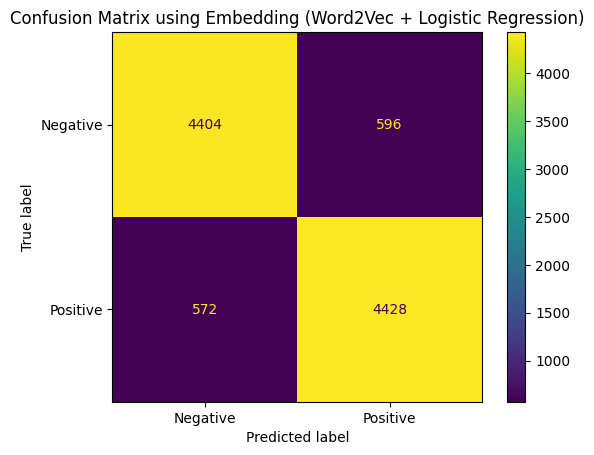

In [98]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

disp_w2v = ConfusionMatrixDisplay(
    confusion_matrix=cm_w2v,
    display_labels=["Negative", "Positive"]
)

disp_w2v.plot()
plt.title("Confusion Matrix using Embedding (Word2Vec + Logistic Regression)")
plt.show()

looks worse than bag of words

also the TF-IDF

# test error 

In [99]:
# Create a temporary DataFrame of your test set results
analysis_df = pd.DataFrame({
    'Clean_Review': X_test,
    'True_Label': y_test.values,
    'Predicted_Label': y_pred_w2v,
    'Confidence': y_proba_w2v
})

# Filter for misclassified reviews where the model was highly confident but wrong
glaring_mistakes = analysis_df[analysis_df['True_Label'] != analysis_df['Predicted_Label']]

# Print 3 examples to read through
for i, row in glaring_mistakes.head(3).iterrows():
    print(f"True Label: {row['True_Label']} | Predicted: {row['Predicted_Label']} (Confidence: {row['Confidence']:.3f})")
    print(f"Review: {row['Clean_Review']}\n{'-'*50}")

True Label: 0 | Predicted: 1 (Confidence: 0.720)
Review: story bride fair amuse engage one filmmaker credit set portray rural minnesotan respect ordinarily reserve coastdwellers weird though find independent movie brainchild single person unambitious clichridden committeebrewed hollywood potboilerthe portrait rural people intend affectionate think character dont ring true mei quite meal smalltown diner never overhear debate merit different nineteenthcentury english novelist one might suggest writerdirector semans experience rural culture coen brother considerably less satiric verve
--------------------------------------------------
True Label: 0 | Predicted: 1 (Confidence: 0.874)
Review: little quentin seem mastered art cake eat itas usual pure sadistic display explain clever thoughtprovoking way send violence back audiences facesure mr tarantino violence baaad sadism baaad well worth wad make point brilliantthe juvenile part audience may well clever enough follow smart reference high 

**bonus :** check for the best numbers of the word2vec model

In [73]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Re-verify our sentences inputs
# (Assuming train_sentences and test_sentences are already defined from previous steps)

# 2. Define the grid of parameters you want to test
vector_sizes_to_test = [50, 100, 150, 200, 250, 300, 350]
windows_to_test = [3, 5, 7, 10]

# Variables to keep track of the absolute best results
best_accuracy = 0.0
best_parameters = {"vector_size": None, "window": None}

print("Starting Grid Search... This might take a few minutes.\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}")
print("-" * 45)

# 3. Start looping through every possible combination
for size in vector_sizes_to_test:
    for win in windows_to_test:
        
        # Train a temporary Word2Vec model with the current combination
        temp_w2v = Word2Vec(
            sentences=train_sentences,
            vector_size=size,
            window=win,
            min_count=2,
            workers=8,
            epochs=5 # Fixed epochs to keep tuning time reasonable
        )
        temp_w2v.init_sims(replace=True)
        
        # Vectorize the training and test sets using our averaging function
        X_train_grid = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
        X_test_grid = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
        
        # Train the Logistic Regression baseline classifier
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train_grid, y_train)
        
        # Generate predictions and evaluate accuracy
        y_pred_grid = clf.predict(X_test_grid)
        current_accuracy = accuracy_score(y_test, y_pred_grid)
        
        # Print the result of the current run to monitor progress
        print(f"{size:<15}{win:<15}{current_accuracy:.4f}")
        
        # If this combination beat the previous high score, save it!
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_parameters["vector_size"] = size
            best_parameters["window"] = win

print("-" * 45)
print(f"GRID SEARCH COMPLETE!")
print(f"Best Test Accuracy: {best_accuracy:.4f}")
print(f"Optimal Parameters found: Vector Size = {best_parameters['vector_size']}, Window = {best_parameters['window']}")

Starting Grid Search... This might take a few minutes.

Vector Size    Window Size    Test Accuracy  
---------------------------------------------


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/679049268.py:34: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


KeyboardInterrupt: 

In [74]:
import time
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Define the new, higher boundary grid
# We start where the last search left off
vector_sizes_to_test = [200, 250, 300]
windows_to_test = [10, 12, 15]
NUM_EPOCHS = 12  # Increased from 5 to 12 to let it train more than twice as long!

best_accuracy = 0.8625  # Setting your current high score as the baseline to beat
best_parameters = {"vector_size": 200, "window": 10}

print(f"Starting Deep Grid Search (Epochs per run: {NUM_EPOCHS})...\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}{'Time Taken':<15}")
print("-" * 60)

for size in vector_sizes_to_test:
    for win in windows_to_test:
        # Skip the exact combination we already know the score for
        if size == 200 and win == 10:
            continue
            
        start_time = time.time()
        
        # Train Word2Vec longer by setting higher epochs
        temp_w2v = Word2Vec(
            sentences=train_sentences,
            vector_size=size,
            window=win,
            min_count=2,
            workers=8,
            epochs=NUM_EPOCHS  # Let the brain study the text longer
        )
        temp_w2v.init_sims(replace=True)
        
        # Vectorize the text rows
        X_train_grid = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
        X_test_grid = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
        
        # Fit the linear classifier
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train_grid, y_train)
        
        # Evaluate
        y_pred_grid = clf.predict(X_test_grid)
        current_accuracy = accuracy_score(y_test, y_pred_grid)
        
        end_time = time.time()
        elapsed_time = end_time - start_time
        
        # Print progress row
        print(f"{size:<15}{win:<15}{current_accuracy:.4f}{elapsed_time:.1f}s")
        
        # Track the absolute champion
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_parameters["vector_size"] = size
            best_parameters["window"] = win

print("-" * 60)
print(f"DEEP TUNING COMPLETE!")
print(f"Absolute Best Test Accuracy: {best_accuracy:.4f}")
print(f"Optimal Configuration: Size = {best_parameters['vector_size']}, Window = {best_parameters['window']}")

Starting Deep Grid Search (Epochs per run: 12)...

Vector Size    Window Size    Test Accuracy  Time Taken     
------------------------------------------------------------


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2567868703.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


200            12             0.876133.8s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2567868703.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


200            15             0.879134.4s


...

300            10             0.873740.6s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2567868703.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


300            12             0.876243.9s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2567868703.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/

300            15             0.876851.8s
------------------------------------------------------------
DEEP TUNING COMPLETE!
Absolute Best Test Accuracy: 0.8791
Optimal Configuration: Size = 200, Window = 15


In [77]:
# Quick test script to find the breaking point
windows_to_test = [50, 55, 60, 65, 70, 75, 80]

for win in windows_to_test:
    temp_w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=200, 
        window=win,
        min_count=2,
        workers=8,
        epochs=12
    )
    temp_w2v.init_sims(replace=True)
    
    X_train_final = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
    X_test_final = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_final, y_train)
    
    acc = clf.score(X_test_final, y_test)
    print(f"Window Size: {win} | Test Accuracy: {acc:.4f}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1997880768.py:13: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


Window Size: 50 | Test Accuracy: 0.8845


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1997880768.py:13: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


Window Size: 55 | Test Accuracy: 0.8836


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1997880768.py:13: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


...

Window Size: 70 | Test Accuracy: 0.8858


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1997880768.py:13: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


Window Size: 75 | Test Accuracy: 0.8849


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1997880768.py:13: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make cal

Window Size: 80 | Test Accuracy: 0.8843


with dimension of 200, window size is 25, we have the test accuracy of 0.8826
Window Size: 40 | Test Accuracy: 0.8841
Window Size: 70 | Test Accuracy: 0.8858

In [78]:
import time
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Fix the winning window size and test dimensions across 200 ± 50 (and higher)
dimensions_to_test = [150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250]
FIXED_WINDOW = 70
NUM_EPOCHS = 12 

print(f"Starting Dimension Sweep (Fixed Window: {FIXED_WINDOW}, Epochs: {NUM_EPOCHS})...\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}{'Time Taken':<15}")
print("-" * 60)

for size in dimensions_to_test:
    start_time = time.time()
    
    # Train Word2Vec with the current dimension size
    temp_w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=size,
        window=FIXED_WINDOW,
        min_count=2,
        workers=8,
        epochs=NUM_EPOCHS
    )
    temp_w2v.init_sims(replace=True)
    
    # Transform rows using our averaging function
    X_train_dim = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
    X_test_dim = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
    
    # Fit the baseline linear classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_dim, y_train)
    
    # Calculate performance
    acc = clf.score(X_test_dim, y_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"{size:<15}{FIXED_WINDOW:<15}{acc:.4f}{elapsed_time:.1f}s")

print("-" * 60)
print("DIMENSION SWEEP COMPLETE!")

Starting Dimension Sweep (Fixed Window: 70, Epochs: 12)...

Vector Size    Window Size    Test Accuracy  Time Taken     
------------------------------------------------------------


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2416044933.py:28: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and wil

150            70             0.883064.5s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2416044933.py:28: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/

160            70             0.884355.2s


...

230            70             0.886073.6s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2416044933.py:28: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


240            70             0.884377.6s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/2416044933.py:28: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


250            70             0.884877.5s
------------------------------------------------------------
DIMENSION SWEEP COMPLETE!


In [79]:
import time
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Zooming in: Testing ±9 around 190 with a step size of 3
# This covers the exact neighborhood you want to explore
dimensions_to_test = [181, 184, 187, 190, 193, 196, 199]
FIXED_WINDOW = 70
NUM_EPOCHS = 12 

best_accuracy = 0.8863  # Setting your new remarkable benchmark as the floor
best_size = 190

print(f"Starting Fine-Grained Dimension Sweep around 190...")
print(f"Fixed Window: {FIXED_WINDOW} | Epochs: {NUM_EPOCHS}\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}{'Time Taken':<15}")
print("-" * 60)

for size in dimensions_to_test:
    # Skip re-running 190 exactly to save time, unless you want to re-verify
    if size == 190:
        print(f"{size:<15}{FIXED_WINDOW:<15}{0.8863:.4f} (Baseline)")
        continue
        
    start_time = time.time()
    
    # Train Word2Vec with the fine-tuned dimension size
    temp_w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=size,
        window=FIXED_WINDOW,
        min_count=2,
        workers=8,
        epochs=NUM_EPOCHS
    )
    temp_w2v.init_sims(replace=True)
    
    # Compress rows using our vector averaging function
    X_train_dim = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
    X_test_dim = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
    
    # Fit the linear classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_dim, y_train)
    
    # Calculate precision accuracy
    acc = clf.score(X_test_dim, y_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"{size:<15}{FIXED_WINDOW:<15}{acc:.4f}{elapsed_time:.1f}s")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_size = size

print("-" * 60)
print("FINE-GRAINED OPTIMIZATION COMPLETE!")
print(f"Absolute Best Performance: {best_accuracy:.4f} at Dimension Size = {best_size}")

Starting Fine-Grained Dimension Sweep around 190...
Fixed Window: 70 | Epochs: 12

Vector Size    Window Size    Test Accuracy  Time Taken     
------------------------------------------------------------


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

181            70             0.885461.7s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1300790856.py:38: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


184            70             0.884159.4s


...

193            70             0.887663.3s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1300790856.py:38: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


196            70             0.885263.4s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1300790856.py:38: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


199            70             0.885966.5s
------------------------------------------------------------
FINE-GRAINED OPTIMIZATION COMPLETE!
Absolute Best Performance: 0.8876 at Dimension Size = 193


In [80]:
import time
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Ultra-fine grid search: Testing the immediate neighbors of 193
dimensions_to_test = [191, 192, 194, 195]
FIXED_WINDOW = 70
NUM_EPOCHS = 12 

best_accuracy = 0.8876  # Your current high score baseline
best_size = 193

print(f"Starting Micro-Optimization Sweep around 193...")
print(f"Fixed Window: {FIXED_WINDOW} | Epochs: {NUM_EPOCHS}\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}{'Time Taken':<15}")
print("-" * 60)

# Print the current benchmark line first for clear comparison
print(f"{193:<15}{FIXED_WINDOW:<15}{0.8876:.4f} (Current Champion)")

for size in dimensions_to_test:
    start_time = time.time()
    
    # Train Word2Vec with micro-tuned dimensions
    temp_w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=size,
        window=FIXED_WINDOW,
        min_count=2,
        workers=8,
        epochs=NUM_EPOCHS
    )
    temp_w2v.init_sims(replace=True)
    
    # Transform dataset rows
    X_train_dim = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
    X_test_dim = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
    
    # Fit linear classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_dim, y_train)
    
    # Evaluate accuracy
    acc = clf.score(X_test_dim, y_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"{size:<15}{FIXED_WINDOW:<15}{acc:.4f}{elapsed_time:.1f}s")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_size = size

print("-" * 60)
print("MICRO-OPTIMIZATION COMPLETE!")
print(f"Absolute Best Performance: {best_accuracy:.4f} at Dimension Size = {best_size}")

Starting Micro-Optimization Sweep around 193...
Fixed Window: 70 | Epochs: 12

Vector Size    Window Size    Test Accuracy  Time Taken     
------------------------------------------------------------
193            70             0.8876 (Current Champion)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/8616499.py:35: DeprecationWarning: Call to deprecated `init_sims

191            70             0.884566.7s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/8616499.py:35: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will b

192            70             0.884867.3s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/8616499.py:35: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


194            70             0.885165.5s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/8616499.py:35: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls 

195            70             0.886166.9s
------------------------------------------------------------
MICRO-OPTIMIZATION COMPLETE!
Absolute Best Performance: 0.8876 at Dimension Size = 193


In [83]:
import time
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Lock the winning dimension size and sweep the window neighborhood
FIXED_SIZE = 193
windows_to_test = [68, 69, 70, 71, 72]
NUM_EPOCHS = 12 

best_accuracy = 0.8876  # Your current absolute champion baseline
best_window = 70

print(f"Starting Fine-Grained Window Sweep around 70...")
print(f"Fixed Dimension Size: {FIXED_SIZE} | Epochs: {NUM_EPOCHS}\n")
print(f"{'Vector Size':<15}{'Window Size':<15}{'Test Accuracy':<15}{'Time Taken':<15}")
print("-" * 60)

for win in windows_to_test:
    # Skip re-running window size 70 to save computation time
    if win == 70:
        print(f"{FIXED_SIZE:<15}{win:<15}{0.8876:.4f} (Current Champion)")
        continue
        
    start_time = time.time()
    
    # Train Word2Vec with the fine-tuned window context net
    temp_w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=FIXED_SIZE,
        window=win,
        min_count=2,
        workers=8,
        epochs=NUM_EPOCHS
    )
    temp_w2v.init_sims(replace=True)
    
    # Transform dataset rows via vector averaging
    X_train_win = np.array([vectorize_review(s, temp_w2v) for s in train_sentences])
    X_test_win = np.array([vectorize_review(s, temp_w2v) for s in test_sentences])
    
    # Fit the linear classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_win, y_train)
    
    # Evaluate precision accuracy
    acc = clf.score(X_test_win, y_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"{FIXED_SIZE:<15}{win:<15}{acc:.4f}{elapsed_time:.1f}s")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_window = win

print("-" * 60)
print("WINDOW NEIGHBORHOOD OPTIMIZATION COMPLETE!")
print(f"Absolute Best Performance: {best_accuracy:.4f} at Window Size = {best_window}")

Starting Fine-Grained Window Sweep around 70...
Fixed Dimension Size: 193 | Epochs: 12

Vector Size    Window Size    Test Accuracy  Time Taken     
------------------------------------------------------------


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1674452127.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and wil

193            68             0.884364.4s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1674452127.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and wil

193            69             0.885064.2s
193            70             0.8876 (Current Champion)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1674452127.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  temp_w2v.init_sims(replace=True)


193            71             0.883965.6s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
/var/folders/3q/9f1hfxls1nxdwg3lymhmly100000gn/T/ipykernel_13621/1674452127.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  te

193            72             0.883466.2s
------------------------------------------------------------
WINDOW NEIGHBORHOOD OPTIMIZATION COMPLETE!
Absolute Best Performance: 0.8876 at Window Size = 70
